# AION Datasets Testing

This notebook tests all 4 AION dataset classes with intelligent caching:
- HSCDataset
- DESIDataset
- EuclidDataset
- EuclidDESIDataset

## Imports

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from aion.datasets import HSCDataset, DESIDataset, EuclidDataset, EuclidDESIDataset, collate_modalities

CACHE_DIR = "../data/"
device = 'cpu'
print(f"Using device: {device}")
print("Note: Using CPU to avoid CUDA device conflicts during notebook execution")

Using device: cpu
Note: Using CPU to avoid CUDA device conflicts during notebook execution


## Test 1: HSCDataset

Testing HSCDataset...
No cache found. Streaming samples from MultimodalUniverse/hsc...


Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Streaming samples:  90%|█████████ | 9/10 [01:41<00:11, 11.27s/it] 


Saving the dataset (0/1 shards):   0%|          | 0/10 [00:00<?, ? examples/s]

Streamed and saved 10 samples to ../data/hsc_slice

Total samples: 10

Batch 1:
  Flux shape: torch.Size([3, 5, 160, 160])
  Bands: ['HSC-G', 'HSC-R', 'HSC-I', 'HSC-Z', 'HSC-Y']
  Device: cpu


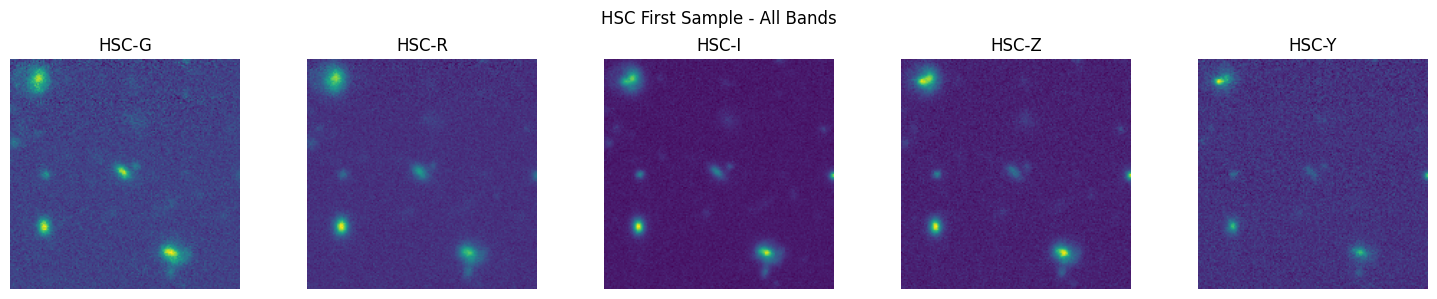


Batch 2:
  Flux shape: torch.Size([3, 5, 160, 160])
  Bands: ['HSC-G', 'HSC-R', 'HSC-I', 'HSC-Z', 'HSC-Y']
  Device: cpu

Batch 3:
  Flux shape: torch.Size([3, 5, 160, 160])
  Bands: ['HSC-G', 'HSC-R', 'HSC-I', 'HSC-Z', 'HSC-Y']
  Device: cpu

Batch 4:
  Flux shape: torch.Size([1, 5, 160, 160])
  Bands: ['HSC-G', 'HSC-R', 'HSC-I', 'HSC-Z', 'HSC-Y']
  Device: cpu


In [2]:
print("Testing HSCDataset...")
hsc_dataset = HSCDataset(
    cache_dir=CACHE_DIR,
    max_entries=10,
    device=device,
    mode="streaming"
)

print(f"\nTotal samples: {len(hsc_dataset)}")

batch_size = 3
hsc_loader = DataLoader(hsc_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_modalities)

for i, batch in enumerate(hsc_loader):
    print(f"\nBatch {i+1}:")
    print(f"  Flux shape: {batch.flux.shape}")
    print(f"  Bands: {batch.bands}")
    print(f"  Device: {batch.flux.device}")
    
    if i == 0:
        fig, axes = plt.subplots(1, 5, figsize=(15, 3))
        fig.suptitle('HSC First Sample - All Bands')
        for band_idx in range(5):
            axes[band_idx].imshow(batch.flux[0, band_idx].cpu().numpy(), cmap='viridis')
            axes[band_idx].set_title(batch.bands[band_idx])
            axes[band_idx].axis('off')
        plt.tight_layout()
        plt.show()

## Test 2: DESIDataset

Testing DESIDataset...
No cache found. Streaming samples from MultimodalUniverse/desi...


Streaming samples:  83%|████████▎ | 5/6 [00:08<00:01,  1.75s/it]


Saving the dataset (0/1 shards):   0%|          | 0/6 [00:00<?, ? examples/s]

Streamed and saved 6 samples to ../data/desi_slice

Total samples: 6

Batch 1:
  Flux shape: torch.Size([3, 7781])
  Ivar shape: torch.Size([3, 7781])
  Wavelength shape: torch.Size([3, 7781])
  Mask shape: torch.Size([3, 7781])
  Device: cpu


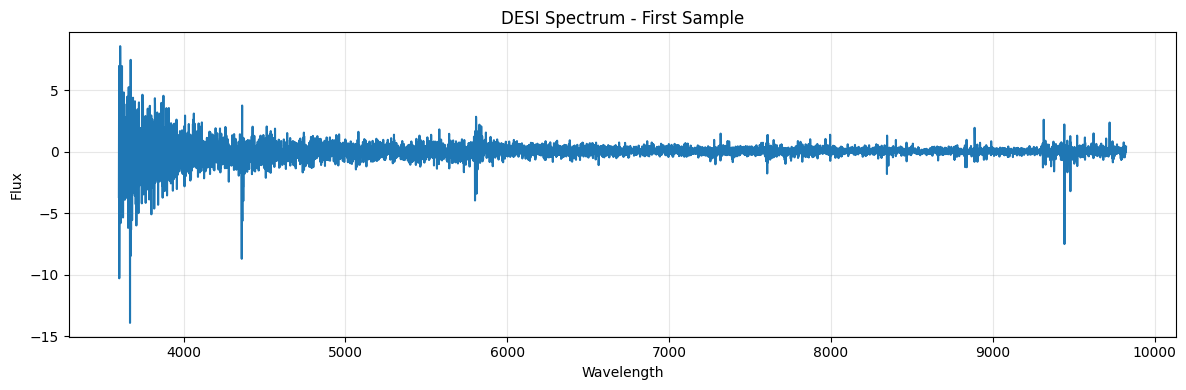


Batch 2:
  Flux shape: torch.Size([3, 7781])
  Ivar shape: torch.Size([3, 7781])
  Wavelength shape: torch.Size([3, 7781])
  Mask shape: torch.Size([3, 7781])
  Device: cpu


In [3]:
print("Testing DESIDataset...")
desi_dataset = DESIDataset(
    cache_dir=CACHE_DIR,
    max_entries=6,
    device=device,
    mode="streaming"
)

print(f"\nTotal samples: {len(desi_dataset)}")

batch_size = 3
desi_loader = DataLoader(desi_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_modalities)

for i, batch in enumerate(desi_loader):
    print(f"\nBatch {i+1}:")
    print(f"  Flux shape: {batch.flux.shape}")
    print(f"  Ivar shape: {batch.ivar.shape}")
    print(f"  Wavelength shape: {batch.wavelength.shape}")
    print(f"  Mask shape: {batch.mask.shape}")
    print(f"  Device: {batch.flux.device}")
    
    if i == 0:
        plt.figure(figsize=(12, 4))
        plt.plot(batch.wavelength[0].cpu().numpy(), batch.flux[0].cpu().numpy())
        plt.xlabel('Wavelength')
        plt.ylabel('Flux')
        plt.title('DESI Spectrum - First Sample')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Test 3: EuclidDataset

Testing EuclidDataset...
No cache found. Streaming samples from msiudek/astroPT_euclid_training_dataset...


Streaming samples:  83%|████████▎ | 5/6 [00:12<00:02,  2.45s/it]


Saving the dataset (0/1 shards):   0%|          | 0/6 [00:00<?, ? examples/s]

Streamed and saved 6 samples to ../data/euclid_slice

Total samples: 6

Batch 1:
  Flux shape: torch.Size([3, 4, 160, 160])
  Bands: ['EUCLID-VIS', 'EUCLID-Y', 'EUCLID-J', 'EUCLID-H']
  Device: cpu


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/matplotlib/colors.py:2294: RuntimeWarning: overflow encountered in subtract
  resdat -= vmin


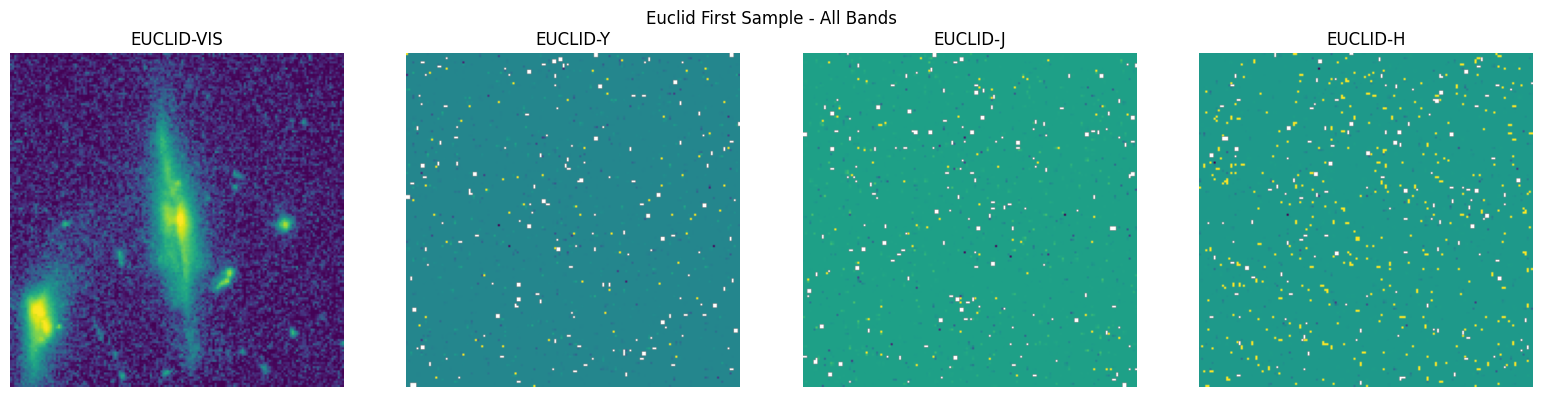


Batch 2:
  Flux shape: torch.Size([3, 4, 160, 160])
  Bands: ['EUCLID-VIS', 'EUCLID-Y', 'EUCLID-J', 'EUCLID-H']
  Device: cpu


In [4]:
print("Testing EuclidDataset...")
try:
    euclid_dataset = EuclidDataset(
        cache_dir=CACHE_DIR,
        max_entries=6,
        device=device,
        split="train_batch_1",
        mode="streaming"
    )

    print(f"\nTotal samples: {len(euclid_dataset)}")

    batch_size = 3
    euclid_loader = DataLoader(euclid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_modalities)

    for i, batch in enumerate(euclid_loader):
        print(f"\nBatch {i+1}:")
        print(f"  Flux shape: {batch.flux.shape}")
        print(f"  Bands: {batch.bands}")
        print(f"  Device: {batch.flux.device}")
        
        if i == 0:
            fig, axes = plt.subplots(1, 4, figsize=(16, 4))
            fig.suptitle('Euclid First Sample - All Bands')
            for band_idx in range(4):
                axes[band_idx].imshow(batch.flux[0, band_idx].cpu().numpy(), cmap='viridis')
                axes[band_idx].set_title(batch.bands[band_idx])
                axes[band_idx].axis('off')
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Error loading Euclid dataset: {e}")
    print("This may be due to network issues or dataset availability.")

## Test 4: EuclidDESIDataset (Combined)

Testing EuclidDESIDataset...
No cache found. Streaming samples from msiudek/astroPT_euclid_desi_dataset...


Streaming samples:  83%|████████▎ | 5/6 [00:10<00:02,  2.19s/it]


Saving the dataset (0/1 shards):   0%|          | 0/6 [00:00<?, ? examples/s]

/home/wassim/Projects/NBody/AION/aion/datasets.py:295: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask=torch.tensor(mask, dtype=torch.bool),


Streamed and saved 6 samples to ../data/euclid_desi_slice

Total samples: 6

Batch 1:
  RGB image shape: torch.Size([3, 224, 224, 3])
  Euclid flux shape: torch.Size([3, 4, 160, 160])
  Euclid bands: ['EUCLID-VIS', 'EUCLID-Y', 'EUCLID-J', 'EUCLID-H']
  DESI flux shape: torch.Size([3, 7781])
  DESI wavelength shape: torch.Size([3, 7781])
  Redshift shape: torch.Size([3, 1])


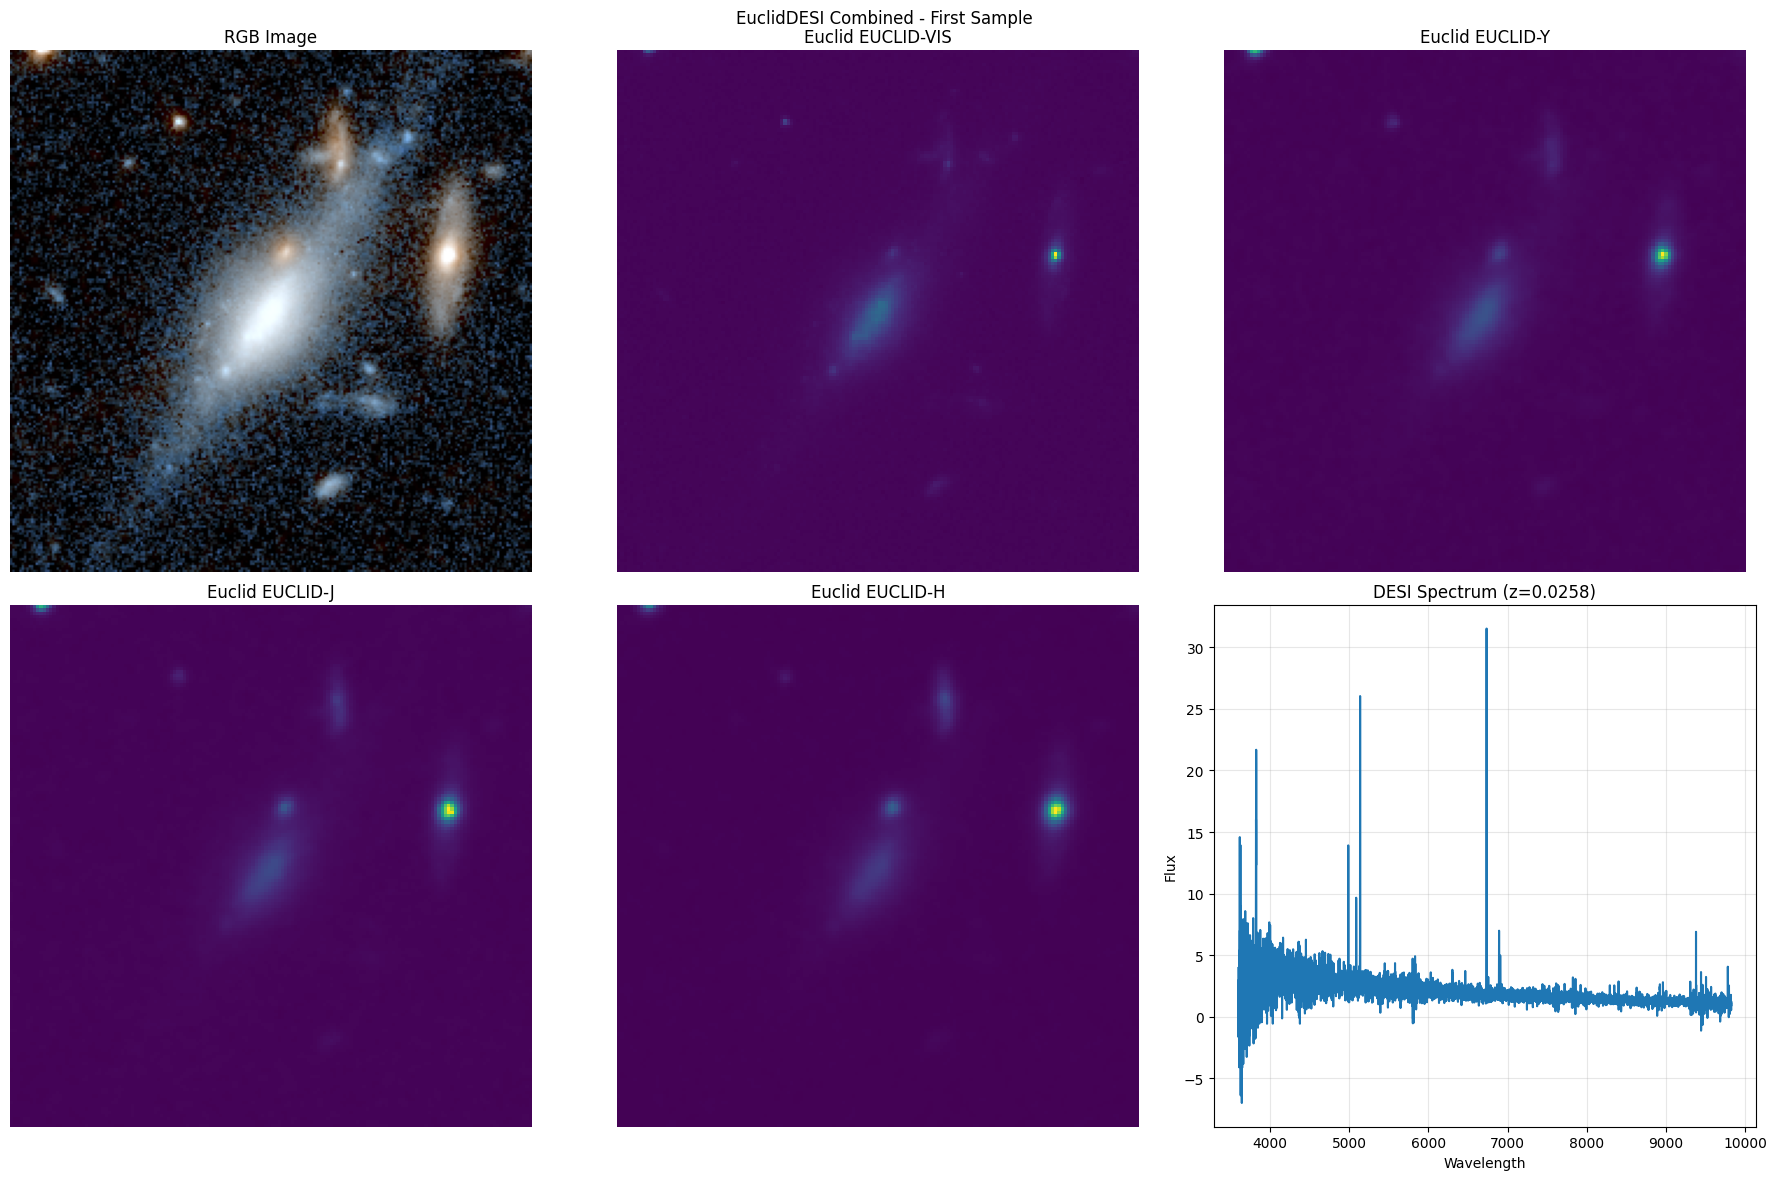


Batch 2:
  RGB image shape: torch.Size([3, 224, 224, 3])
  Euclid flux shape: torch.Size([3, 4, 160, 160])
  Euclid bands: ['EUCLID-VIS', 'EUCLID-Y', 'EUCLID-J', 'EUCLID-H']
  DESI flux shape: torch.Size([3, 7781])
  DESI wavelength shape: torch.Size([3, 7781])
  Redshift shape: torch.Size([3, 1])


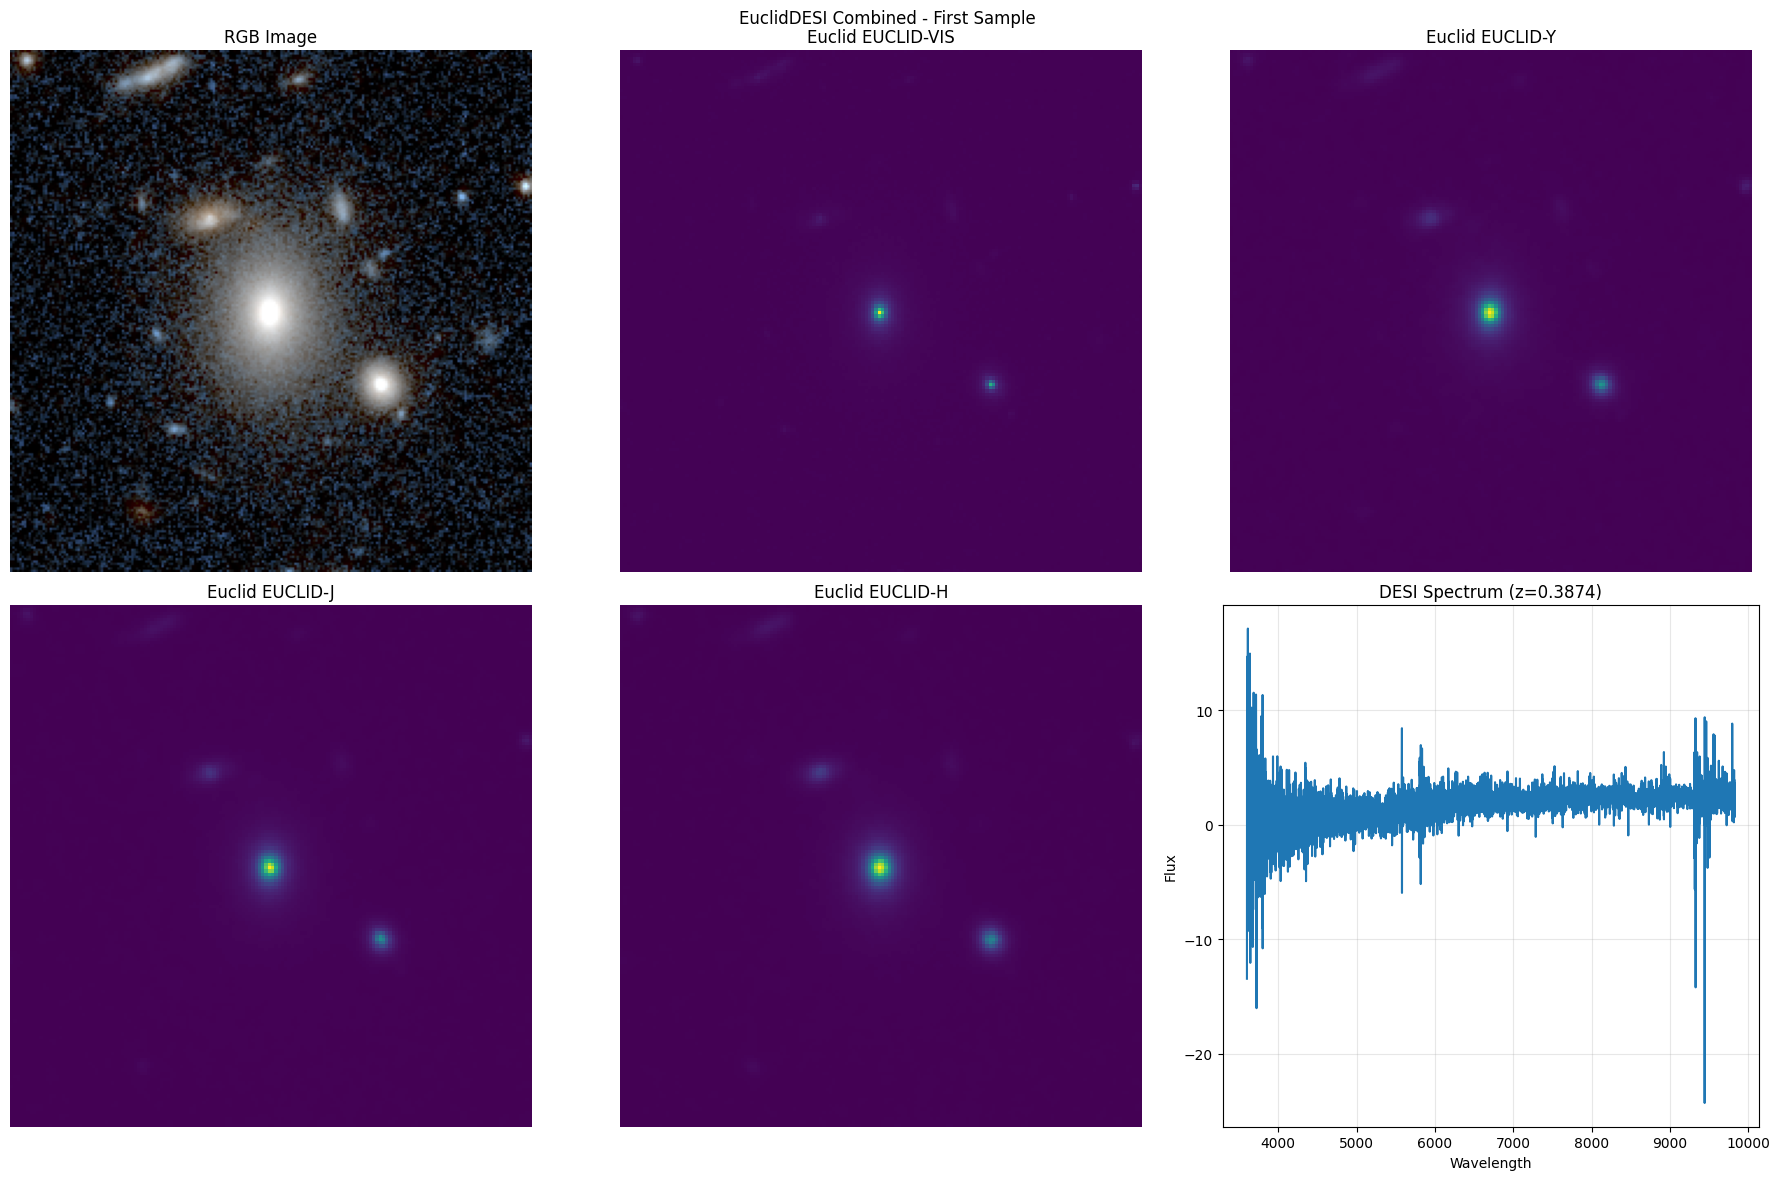

In [5]:
print("Testing EuclidDESIDataset...")
try:
    euclid_desi_dataset = EuclidDESIDataset(
        cache_dir=CACHE_DIR,
        max_entries=6,
        device=device,
        mode="streaming"
    )

    print(f"\nTotal samples: {len(euclid_desi_dataset)}")

    batch_size = 3
    euclid_desi_loader = DataLoader(euclid_desi_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_modalities)

    for i, (rgb_batch, euclid_batch, desi_batch, redshift_batch) in enumerate(euclid_desi_loader):
        print(f"\nBatch {i+1}:")
        print(f"  RGB image shape: {rgb_batch.shape}")
        print(f"  Euclid flux shape: {euclid_batch.flux.shape}")
        print(f"  Euclid bands: {euclid_batch.bands}")
        print(f"  DESI flux shape: {desi_batch.flux.shape}")
        print(f"  DESI wavelength shape: {desi_batch.wavelength.shape}")
        print(f"  Redshift shape: {redshift_batch.value.shape}")
        
        if i == 1 or True:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            fig.suptitle('EuclidDESI Combined - First Sample')
            
            axes[0, 0].imshow(rgb_batch[0].cpu().numpy())
            axes[0, 0].set_title('RGB Image')
            axes[0, 0].axis('off')
            
            for band_idx in range(4):
                row = (band_idx + 1) // 3
                col = (band_idx + 1) % 3
                axes[row, col].imshow(euclid_batch.flux[0, band_idx].cpu().numpy(), cmap='viridis')
                axes[row, col].set_title(f'Euclid {euclid_batch.bands[band_idx]}')
                axes[row, col].axis('off')
            
            axes[1, 2].plot(desi_batch.wavelength[0].cpu().numpy(), desi_batch.flux[0].cpu().numpy())
            axes[1, 2].set_xlabel('Wavelength')
            axes[1, 2].set_ylabel('Flux')
            axes[1, 2].set_title(f'DESI Spectrum (z={redshift_batch.value[0].item():.4f})')
            axes[1, 2].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Error loading EuclidDESI dataset: {e}")
    print("This may be due to network issues or dataset availability.")

## Test 5: Incremental Caching Behavior

In [6]:
print("Testing incremental caching with HSCDataset...\n")

print("=" * 60)
print("Loading 6 samples (max_entries=6, mode='streaming')...")
print("=" * 60)
ds1 = HSCDataset(cache_dir=CACHE_DIR, max_entries=6, device=device, mode="streaming")
print(f"Dataset length: {len(ds1)}")

print("\n" + "=" * 60)
print("Loading 12 samples (max_entries=12, mode='streaming')...")
print("Expected: Load 6 from cache, stream 6 more")
print("=" * 60)
ds2 = HSCDataset(cache_dir=CACHE_DIR, max_entries=12, device=device, mode="streaming")
print(f"Dataset length: {len(ds2)}")

print("\n" + "=" * 60)
print("Loading 6 samples again (max_entries=6, mode='streaming')...")
print("Expected: Load all 6 from cache (no streaming)")
print("=" * 60)
ds3 = HSCDataset(cache_dir=CACHE_DIR, max_entries=6, device=device, mode="streaming")
print(f"Dataset length: {len(ds3)}")

print("\n" + "=" * 60)
print("Caching test completed!")
print("=" * 60)

Testing incremental caching with HSCDataset...

Loading 6 samples (max_entries=6, mode='streaming')...
Loaded 6 samples from disk: ../data/hsc_slice
Dataset length: 6

Loading 12 samples (max_entries=12, mode='streaming')...
Expected: Load 6 from cache, stream 6 more
Found 10 cached samples, need 12. Streaming additional samples...


Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

Saving the dataset (0/1 shards):   0%|          | 0/12 [00:00<?, ? examples/s]

Streamed 2 additional samples and saved to ../data/hsc_slice
Dataset length: 12

Loading 6 samples again (max_entries=6, mode='streaming')...
Expected: Load all 6 from cache (no streaming)
Loaded 6 samples from disk: ../data/hsc_slice
Dataset length: 6

Caching test completed!


## Summary

This notebook successfully tested:

1. **HSCDataset**: Loads HSC images with 5 bands (HSC-G, HSC-R, HSC-I, HSC-Z, HSC-Y)
2. **DESIDataset**: Loads DESI spectra with flux, ivar, wavelength, and mask
3. **EuclidDataset**: Loads Euclid images with 4 bands (EUCLID-VIS, EUCLID-Y, EUCLID-J, EUCLID-H)
4. **EuclidDESIDataset**: Loads RGB image, Euclid image, DESI spectrum, and redshift (4-tuple)
5. **Incremental Caching**: Demonstrates intelligent cache behavior that avoids re-streaming

All datasets support:
- **Streaming mode**: Downloads and caches samples, controlled by `max_entries` parameter
- **Local mode**: Loads from existing cache only (use `mode="local"`)
- PyTorch DataLoader integration for batching
- Automatic device placement (CPU/CUDA)
- Conversion to AION modality objects